# Motores de Busca Léxico e Semântico: TF-IDF *versus* Word2Vec — Gabriel Viana e João Victor

**Trabalho Prático 2** — Módulo II: Representação Vetorial de Textos

Optamos por utilizar o mesmo corpus constituído no e tratado no TP1, nosso objetivo com essa abordagem foi buscar uma continuidade na análise dos dados das avaliações públicas de aplicativos de ensino superior no Brasil; Utilizamos dois motores de busca sobre essa base de dados, um léxico e um semântico para verificar através de testes de estresse qual se comporta melhor perante a falta de correspondência exata de palavras.

### Roteiro

| Seção | Conteúdo |
|---|---|
| 1 | Configuração do ambiente |
| 2 | **Fase 1** — carga do corpus e pipeline de pré-processamento do TP1 |
| 3 | **Fase 2** — motor de busca léxico (TF-IDF, representação esparsa) |
| 4 | **Fase 3** — motor de busca semântico (Word2Vec NILC, representação densa) |
| 5 | Teste de estresse: consulta sem correspondência léxica |
| 6 | Análise crítica comparativa |

## 1. Configuração do Ambiente

Como essa aplicação está sendo desenvolvida no Google Colab, foi nescessária a instalação de 3 dependências externas.

- gensim: Uma bliblioteca especializada em Word2Vec, a mesma recebe as palavras e os vetores referentes e monta um dicionário que fornece essas referências.
- pt_core_news_sm: Um modelo treinado para entender a gramática do português, permitindo que palavras conjudas de formas diferentes não constem como palavras diferentes.
- safetensors: Uma ferramenta que permite a leitura dos arquivos da Word2Vec.

Além dessas ainda utilizamos as bibliotecas nativas do colab, "scikit-learn","pandas","nltk" e "huggingface_hub".


In [1]:
# Instalação das dependências
!pip install -q "gensim>=4.4" safetensors huggingface_hub scikit-learn nltk spacy pandas matplotlib
!python -m spacy download pt_core_news_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 19.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 97.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [23]:
import re
import time
import warnings
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import sklearn
import spacy
import gensim
from gensim.models import KeyedVectors
from huggingface_hub import hf_hub_download
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from safetensors.numpy import load_file
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)

for recurso in ["stopwords", "rslp"]:
    nltk.download(recurso, quiet=True)

#Mesma configuração do TP1: parser e NER desligados; tagger e attribute_ruler
#Permanecem, porque o lematizador de português depende da classe gramatical.
NLP = spacy.load("pt_core_news_sm", disable=["parser", "ner"])

print(f"pandas        {pd.__version__}")
print(f"scikit-learn  {sklearn.__version__}")
print(f"gensim        {gensim.__version__}")
print(f"spaCy         {spacy.__version__}  |  modelo: pt_core_news_sm {NLP.meta['version']}")

pandas        2.2.3
scikit-learn  1.6.1
gensim        4.4.0
spaCy         3.8.16  |  modelo: pt_core_news_sm 3.8.0


## 2. Fase 1 — Preparação e Pré-Processamento

### 2.1 Carga do corpus

No TP1, a base de dados era coletada em tempo real da Play Store, sendo ordenados pela data de postegem das avaliações, porém, nessa segunda etapa do trabalho, é nescessário trabalhar com um corpus estático; Para tal solução foi gerado através do próprio código da seção 1 um arquivo CSV "corpus_educacao_bruto.csv", esse arquivo será a base trabalhado daqui em diante.

Esse arquivo pode ser acessado através de um repositório do Github, que contém tanto os códigos dos dois trabalhos quanto os demais arquivos relevantes:

- Acesso ao Github do projeto: https://github.com/gabrielferreirafilgueirasviana-max/nlp-educacao-tp1-tp2

In [3]:
ARQUIVO_CORPUS = Path("corpus_educacao_bruto.csv")

# Cópia congelada do corpus no repositório do trabalho (link "raw" do GitHub)
URL_CORPUS = "https://raw.githubusercontent.com/gabrielferreirafilgueirasviana-max/nlp-educacao-tp1-tp2/main/corpus_educacao_bruto.csv"


def carregar_corpus() -> pd.DataFrame:
    # Carrega o corpus congelado do TP1 a partir do arquivo local, da URL ou de upload.
    if ARQUIVO_CORPUS.exists():
        origem = f"arquivo local ({ARQUIVO_CORPUS})"
        corpus = pd.read_csv(ARQUIVO_CORPUS)
    elif URL_CORPUS:
        origem = f"URL ({URL_CORPUS})"
        corpus = pd.read_csv(URL_CORPUS)
    else:
        try:
            from google.colab import files
        except ImportError as erro:
            raise FileNotFoundError(
                f"{ARQUIVO_CORPUS} não encontrado e URL_CORPUS vazia."
            ) from erro
        print(f"Envie o arquivo {ARQUIVO_CORPUS.name}:")
        enviado = files.upload()
        nome = next(iter(enviado))
        Path(nome).rename(ARQUIVO_CORPUS)
        origem = "upload no Colab"
        corpus = pd.read_csv(ARQUIVO_CORPUS)

    print(f"Corpus carregado de: {origem}")
    return corpus


df = carregar_corpus()

# Verificação dos requisitos mínimos do enunciado
assert len(df) >= 200, "O corpus precisa de ao menos 200 documentos."
assert df["texto"].notna().all()

palavras_por_doc = df["texto"].str.split().str.len()
print(f"Documentos .................. {len(df):>7,}")
print(f"Instituições ................ {df['instituicao'].nunique():>7}")
print(f"Palavras por documento ...... média {palavras_por_doc.mean():.1f} | "
      f"mediana {palavras_por_doc.median():.0f} | mín. {palavras_por_doc.min()} | máx. {palavras_por_doc.max()}")

display(df[["instituicao", "nota", "texto"]].sample(5, random_state=42))

Corpus carregado de: URL (https://raw.githubusercontent.com/gabrielferreirafilgueirasviana-max/nlp-educacao-tp1-tp2/main/corpus_educacao_bruto.csv)
Documentos ..................   2,452
Instituições ................       9
Palavras por documento ...... média 24.4 | mediana 18 | mín. 2 | máx. 97


,instituicao,nota,texto
2114,Descomplica Faculdade,1,"não funciona no meu smartphone, não abre nada só fica girando o logo"
700,Anhanguera,1,Não dá para colocar em tela cheia as vídeo aulas. O botão simplesmente não funciona. exercícios sem enunciado e questões de outras matérias.
1165,UNINTER,1,Tá bem ruim não entra em ND
2416,Descomplica Faculdade,5,Experiência excepcional!
1626,Cruzeiro do Sul Virtual,5,A experiência tem sido positiva.


### 2.2 Pipeline de pré-processamento do TP1

A classe abaixo é **copiada sem alterações** do TP1: higienização por 13 expressões regulares (incluindo a remoção de dados pessoais para conformidade com a LGPD), tokenização pelo spaCy, remoção de stop words estendida com o jargão setorial, marcação de escopo de negação (`não funciona` → `nao_funcionar`) e lematização. As decisões e justificativas de cada estágio estão documentadas no notebook do TP1.

In [4]:
@dataclass
class PipelineTextual:
    #Pipeline de pré-processamento textual para triagem de manifestações.

    jargao_setorial: tuple[str, ...] = ()
    normalizador: str = "lematizacao"
    tamanho_minimo_token: int = 3
    janela_negacao: int = 1

    stop_words: frozenset = field(init=False)
    _stemmer: RSLPStemmer = field(init=False, repr=False)

    # Negadores: preservados contra o dicionário padrão e usados para marcar
    # o escopo da negação na normalização. Ver Seção 5.3.
    NEGADORES = frozenset({"não", "nao", "nem", "nunca", "jamais", "sem"})

    REGRAS_REGEX = [
        ("html",        re.compile(r"<[^>]+>"), " "),
        ("url",         re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE), " "),
        ("email",       re.compile(r"\b[\w.+-]+@[\w-]+\.[\w.]+\b"), " "),
        ("identificador", re.compile(r"\b(?:protocolo|matr[íi]cula|chamado|ticket|cpf|rg|ra)\s*"
                                     r"(?:n[º°o]?\.?)?\s*[:\-]?\s*[\d.\-]{3,}", re.IGNORECASE), " "),
        ("cpf",         re.compile(r"(?<!\d)\d{3}\.?\d{3}\.?\d{3}-?\d{2}(?!\d)"), " "),
        ("telefone",    re.compile(r"(?<!\d)\(?\d{2}\)?\s?9?\d{4}[-.\s]?\d{4}(?!\d)"), " "),
        ("valor",       re.compile(r"r\$\s?\d+(?:[.,]\d+)*", re.IGNORECASE), " "),
        ("data",        re.compile(r"\b\d{1,2}[/\-.]\d{1,2}(?:[/\-.]\d{2,4})?\b"), " "),
        ("emoji",       re.compile("[\U00002190-\U000021FF\U00002300-\U000027BF"
                                   "\U0001F000-\U0001FAFF\U0000FE0F\U00002B00-\U00002BFF]+"), " "),
        ("riso",        re.compile(r"\b(?:[kh]{3,}|(?:rs){2,}|(?:ha|hu?a|he){2,})\b",
                                   re.IGNORECASE), " "),
        ("alongamento", re.compile(r"(\w)\1{2,}"), r"\1"),
        ("nao_alfabetico", re.compile(r"[^A-Za-zÀ-ÖØ-öø-ÿ\s]"), " "),
        ("espaco",      re.compile(r"\s{2,}"), " "),
    ]

    def __post_init__(self):
        if self.normalizador not in {"lematizacao", "stemming"}:
            raise ValueError("normalizador deve ser 'lematizacao' ou 'stemming'")
        # Os negadores são subtraídos do dicionário: eles sobrevivem à
        # filtragem e são consumidos depois, na marcação de escopo.
        self.stop_words = (
            frozenset(stopwords.words("portuguese"))
            | frozenset(self.jargao_setorial)
        ) - self.NEGADORES
        self._stemmer = RSLPStemmer()

    def limpar(self, texto: str) -> str:
        #Aplica a cadeia de expressões regulares ao texto bruto.
        limpo = str(texto)
        for _, padrao, substituto in self.REGRAS_REGEX:
            limpo = padrao.sub(substituto, limpo)
        return limpo.strip()

    def limpar_por_etapa(self, texto: str) -> dict[str, str]:
        #Retorna a saída acumulada após cada regra — usado no teste de sanidade.
        parcial, historico = str(texto), {}
        for nome, padrao, substituto in self.REGRAS_REGEX:
            parcial = padrao.sub(substituto, parcial)
            historico[nome] = parcial.strip()
        return historico

    def _mantem(self, token: str) -> bool:
        #Critério de permanência: não é stop word e tem tamanho mínimo.
        return token not in self.stop_words and len(token) >= self.tamanho_minimo_token

    def _pares(self, documento) -> list[tuple[str, str]]:
        #Extrai pares (forma, forma normalizada) de um documento já analisado.

        if self.normalizador == "stemming":
            return [(t.text.lower(), self._stemmer.stem(t.text.lower()))
                    for t in documento if t.is_alpha]
        return [(t.text.lower(), t.lemma_.lower()) for t in documento if t.is_alpha]

    def _aplicar_negacao(self, pares: list[tuple[str, str]]) -> list[str]:
        #Filtra e aplica marcação de escopo de negação.

        saida, escopo_pendente = [], 0

        for forma, norma in pares:
            if forma in self.NEGADORES:
                escopo_pendente = self.janela_negacao
                continue
            if not (self._mantem(forma) and self._mantem(norma)):
                continue
            if escopo_pendente:
                saida.append(f"nao_{norma}")
                escopo_pendente -= 1
            else:
                saida.append(norma)

        return saida

    def _componentes_desligados(self) -> list[str]:
        #No modo stemming a análise morfológica é dispensável e é desligada.
        return ["tagger", "attribute_ruler", "lemmatizer"] if self.normalizador == "stemming" else []

    def estagios_corpus(self, textos) -> dict[str, list[list[str]]]:
        #Executa o pipeline em lote e devolve a saída de cada estágio.

        tokenizado, sem_stop_words, normalizado = [], [], []
        limpos = (self.limpar(texto) for texto in textos)

        for documento in NLP.pipe(limpos, batch_size=256,
                                  disable=self._componentes_desligados()):
            pares = self._pares(documento)
            tokenizado.append([forma for forma, _ in pares])
            sem_stop_words.append([forma for forma, _ in pares if self._mantem(forma)])
            normalizado.append(self._aplicar_negacao(pares))

        return {
            "tokenizado": tokenizado,
            "sem_stop_words": sem_stop_words,
            "normalizado": normalizado,
        }

    def estagios(self, texto: str) -> dict[str, list[str]]:
        #Versão de documento único de `estagios_corpus`.

        return {fase: saida[0] for fase, saida in self.estagios_corpus([texto]).items()}

    def processar(self, texto: str) -> list[str]:
        #Executa o pipeline completo sobre um documento.

        return self.estagios(texto)["normalizado"]

    def processar_corpus(self, textos) -> list[list[str]]:
        #Executa o pipeline completo sobre uma coleção de documentos.

        return self.estagios_corpus(textos)["normalizado"]

In [5]:
JARGAO_SETORIAL = (
    # Artefato avaliado
    "app", "aplicativo", "apk", "celular", "estrela", "estrelas",
    # Entidade institucional
    "faculdade", "universidade", "instituição", "instituicao", "unopar",
    "estácio", "estacio", "anhanguera", "uninter", "uniasselvi", "unip", "descomplica",
    # Vocabulário acadêmico genérico
    "aluno", "alunos", "aluna", "curso", "cursos", "estudante", "ead",
    # Gíria e abreviação de internet
    # (o riso — kkkk, rsrs, hahaha — é eliminado antes, pela regra de regex nº 10)
    "vcs", "pfv", "pff", "vlw", "tbm", "pra", "pro", "né",
    "obs", "msm", "qnd", "blz", "sdd", "tipo",
)

### 2.3 Ajustes ao pipeline identificados neste trabalho

Ao revisitar o pipeline do TP1 acabamos detectando dois defeitos que anteriormente tinham passado despercebidos, sendo eles:

- Contrações decompostas em lemas com espaço: O spaCy estava gerando alguns erros de lematização, como "desse" virando "de esse" e "nele" se tornando "em ele", como esses lemas resultantes não constam no dicionário de stop words os mesmos passam direto pelo filtro.
- Lemas inexistentes em termos centrais do domínio: elementos como "consigo", a depender do contexto, de tornanvam em "consigo", "consigar","com si", "consigir" e "consiger", como resultado, uma queixa frequente ficava fragmentada em 5 colunas distintas.

A correção é feita por uma subclasse que **preserva integralmente o pipeline do TP1** e intervém apenas sobre os pares (forma, lema) já calculados; Abaixo segue uma célula que contem o procedimento realizado para corrigir pontualmente os erros de lematização detectados na tabela.

In [6]:
# Correções indexadas pela FORMA superficial (minúscula) -> lema correto.
# Levantadas a partir dos lemas que o spaCy produz sobre este corpus (ver saída abaixo).
CORRECOES_LEMA = {
    # verbos centrais do domínio
    "consigo": "conseguir", "trava": "travar", "travam": "travar",
    "demora": "demorar", "demoram": "demorar", "desinstalei": "desinstalar",
    "resolvam": "resolver", "resolva": "resolver", "assisto": "assistir",
    "arrumem": "arrumar", "corrijam": "corrigir", "corrigido": "corrigir",
    "corrigida": "corrigir", "responde": "responder", "somem": "sumir",
    "amei": "amar", "reclamei": "reclamar", "fiz": "fazer", "acesse": "acessar",
    "atualizem": "atualizar", "recomendo": "recomendar",
    # substantivos e adjetivos lematizados como verbos inexistentes
    "senha": "senha", "online": "online", "aprendizado": "aprendizado",
    "desatualizado": "desatualizado", "desatualizada": "desatualizado",
    "satisfeita": "satisfeito", "ótimas": "bom", "inválido": "inválido",
    "aulas": "aula",
    "carteirinha": "carteirinha",
}


@dataclass
class PipelineBusca(PipelineTextual):
    # Pipeline do TP1 acrescido da correção de lemas descrita na Seção 2.3.

    correcoes: dict = field(default_factory=lambda: dict(CORRECOES_LEMA))

    def _pares(self, documento) -> list[tuple[str, str]]:
        pares = []
        for forma, lema in super()._pares(documento):
            if forma in self.correcoes:
                lema = self.correcoes[forma]
            elif " " in lema:          # contração: de esse, em ele, com si...
                continue
            pares.append((forma, lema))
        return pares


# Evidência: lema original do spaCy para cada forma corrigida, com frequência no corpus.
pipeline_tp1 = PipelineTextual(jargao_setorial=JARGAO_SETORIAL)
lemas_originais = Counter()
for documento in NLP.pipe((pipeline_tp1.limpar(t) for t in df["texto"]), batch_size=256):
    for forma, lema in PipelineTextual._pares(pipeline_tp1, documento):
        if not pipeline_tp1._mantem(forma):   # palavra funcional: já descartada no TP1
            continue
        if forma in CORRECOES_LEMA or " " in lema:
            lemas_originais[(forma, lema)] += 1

evidencia = (
    pd.DataFrame(
        [(f, l, CORRECOES_LEMA.get(f, "(descartado)"), n) for (f, l), n in lemas_originais.items()],
        columns=["forma", "lema do spaCy", "lema corrigido", "ocorrências"],
    )
    .query("`lema do spaCy` != `lema corrigido`")
    .sort_values("ocorrências", ascending=False)
    .reset_index(drop=True)
)
print(f"{len(evidencia)} pares (forma, lema) afetados | "
      f"{evidencia['ocorrências'].sum():,} ocorrências no corpus\n")
display(evidencia.head(20))

79 pares (forma, lema) afetados | 1,026 ocorrências no corpus



,forma,lema do spaCy,lema corrigido,ocorrências
0,consigo,consigo,conseguir,157
1,consigo,consigar,conseguir,139
2,trava,trar,travar,100
3,consigo,com si,conseguir,86
4,fiz,fiz,fazer,45
5,demora,demora,demorar,36
6,disso,de isso,(descartado),30
7,desse,de esse,(descartado),27
8,dessa,de esse,(descartado),24
9,nesse,em esse,(descartado),23


In [7]:
pipeline = PipelineBusca(jargao_setorial=JARGAO_SETORIAL, normalizador="lematizacao")

inicio = time.perf_counter()
df["tokens"] = pipeline.processar_corpus(df["texto"])
print(f"Corpus processado em {time.perf_counter() - inicio:.1f} s\n")

# Comparação com o pipeline original do TP1, sobre o mesmo corpus
tokens_tp1 = pipeline_tp1.processar_corpus(df["texto"])

def perfil(listas):
    achatado = [t for tokens in listas for t in tokens]
    contagem = Counter(achatado)
    return len(achatado), len(contagem), contagem

tok_tp1, voc_tp1, cont_tp1 = perfil(tokens_tp1)
tok_tp2, voc_tp2, cont_tp2 = perfil(df["tokens"])

print(f"{'':<34}{'TP1':>10}{'TP2':>10}")
print(f"{'Tokens após o pipeline':<34}{tok_tp1:>10,}{tok_tp2:>10,}")
print(f"{'Vocabulário (termos únicos)':<34}{voc_tp1:>10,}{voc_tp2:>10,}")
print("\nConsolidação da queixa 'não consigo':")
for termo in ["nao_consigo", "nao_consigar", "nao_com si", "nao_consigir", "nao_consiger", "nao_conseguir"]:
    print(f"  {termo:<16} TP1: {cont_tp1.get(termo, 0):>4}   TP2: {cont_tp2.get(termo, 0):>4}")

vazios = df["tokens"].str.len().eq(0).sum()
print(f"\nDocumentos que ficaram sem nenhum token após o pipeline: {vazios}")

Corpus processado em 5.8 s

                                         TP1       TP2
Tokens após o pipeline                29,032    28,842
Vocabulário (termos únicos)            4,025     3,951

Consolidação da queixa 'não consigo':
  nao_consigo      TP1:  116   TP2:    0
  nao_consigar     TP1:  137   TP2:    0
  nao_com si       TP1:   78   TP2:    0
  nao_consigir     TP1:    5   TP2:    0
  nao_consiger     TP1:    2   TP2:    0
  nao_conseguir    TP1:  134   TP2:  472

Documentos que ficaram sem nenhum token após o pipeline: 2


Uma amostra do resultado final da Fase 1:

In [8]:
for linha in df.sample(4, random_state=7).itertuples():
    print("=" * 100)
    print(f"[{linha.instituicao} | nota {linha.nota}]")
    print(f"ORIGINAL : {linha.texto[:250]}")
    print(f"TOKENS   : {linha.tokens}")
print("=" * 100)

[Descomplica Faculdade | nota 1]
ORIGINAL : Simplesmente o app não permite que eu acesse o curso. Fiz minha inscrição pelo botão Google e não tem o botão para entrar, apenas o acesso com e-mail e senha. adquiri a pós hj e já estou com esse tipo de problema. não tem nenhum tipo de chat que não 
TOKENS   : ['simplesmente', 'nao_permitir', 'acessar', 'fazer', 'inscrição', 'botão', 'google', 'nao_botão', 'entrar', 'apenas', 'acesso', 'mail', 'senha', 'adquirir', 'pós', 'problema', 'nao_nenhum', 'chat', 'nao_robô']
[Estácio | nota 2]
ORIGINAL : Pessoal, o APP demora D+ para abrir. Chega em 50% e trava geral. Favor verificar...
TOKENS   : ['pessoal', 'demorar', 'abrir', 'chega', 'travar', 'geral', 'favor', 'verificar']
[Descomplica Faculdade | nota 2]
ORIGINAL : a atualização anterior era bem melhor, tinha a opção de Assistir offline e além disso demora muito para abrir tendo dia que nem abre a aula
TOKENS   : ['atualização', 'anterior', 'bem', 'bom', 'opção', 'assistir', 'offline', 'além', 

## 3. Fase 2 — Motor de Busca Léxico (TF-IDF, representação esparsa)

### 3.1 Vetorização

O `TfidfVectorizer` recebe os documentos **já tokenizados** pela Fase 1. Por padrão, ele aplicaria sua própria tokenização (expressão regular `\b\w\w+\b`) e sua própria conversão para caixa baixa, o que descartaria o trabalho do pipeline em particular, quebraria `nao_funcionar` em `nao` e `funcionar` e desfaria a marcação de negação. Para evitar isso, o parâmetro `analyzer` recebe uma função identidade: a lista de tokens entra na matriz exatamente como saiu do pipeline.

Cada documento $d$ vira um vetor $\mathbf{d} \in \mathbb{R}^{|V|}$, uma coordenada por termo do vocabulário $V$:

$$
w_{t,d} = \mathrm{tf}(t,d)\cdot \mathrm{idf}(t), \qquad \mathrm{idf}(t) = \ln\frac{1+N}{1+\mathrm{df}(t)} + 1
$$

em que $\mathrm{tf}(t,d)$ é a contagem do termo no documento, $N$ o total de documentos e $\mathrm{df}(t)$ o número de documentos que contêm $t$ (fórmula com suavização, padrão do scikit-learn). Cada vetor é então normalizado para norma L2 unitária, de modo que o produto escalar entre dois vetores já é o cosseno entre eles.

In [9]:
def analisador_identidade(tokens: list[str]) -> list[str]:
    # Entrega ao vetorizador os tokens da Fase 1 sem nenhuma re-tokenização.
    return tokens


vetorizador_tfidf = TfidfVectorizer(
    analyzer=analisador_identidade,  # tokens já processados pela Fase 1
    lowercase=False,                 # a caixa baixa já foi aplicada no pipeline
    norm="l2",                       # vetores unitários: produto escalar = cosseno
    smooth_idf=True,
)
matriz_tfidf = vetorizador_tfidf.fit_transform(df["tokens"])

n_docs, n_termos = matriz_tfidf.shape
nao_nulos = matriz_tfidf.nnz
densidade = nao_nulos / (n_docs * n_termos)

print(f"Matriz termo-documento ........ {n_docs:,} documentos x {n_termos:,} termos")
print(f"Tipo .......................... {type(matriz_tfidf).__name__} (esparsa)")
print(f"Células não nulas ............. {nao_nulos:,} de {n_docs * n_termos:,}")
print(f"Densidade ..................... {densidade:.3%}")
print(f"Esparsidade ................... {1 - densidade:.3%}")
print(f"Termos não nulos por documento  média {nao_nulos / n_docs:.1f}")

idf = pd.Series(vetorizador_tfidf.idf_, index=vetorizador_tfidf.get_feature_names_out())
print("\nTermos de menor idf (mais comuns):", ", ".join(idf.nsmallest(8).index))
print("Termos de maior idf (mais raros): ", ", ".join(idf.nlargest(8).index))

Matriz termo-documento ........ 2,452 documentos x 3,951 termos
Tipo .......................... csr_matrix (esparsa)
Células não nulas ............. 27,059 de 9,687,852
Densidade ..................... 0.279%
Esparsidade ................... 99.721%
Termos não nulos por documento  média 11.0

Termos de menor idf (mais comuns): bom, nao_conseguir, aula, fazer, ficar, acessar, todo, bem
Termos de maior idf (mais raros):  aac, aatw, abar, abençoe, abessa, abordagem, aborrecimento, abra


### 3.2 Mecanismo de busca

A função `buscar_tfidf` aplica à consulta **exatamente o mesmo pipeline** do corpus (`pipeline.processar`), projeta-a no espaço do vetorizador já treinado com `transform` (nunca `fit_transform`, que recalcularia o vocabulário e o idf a partir da própria consulta) e calcula a similaridade de cosseno contra todos os documentos.

Um caso de borda precisa de tratamento explícito: se nenhum termo da consulta pertence ao vocabulário, o vetor da consulta é **nulo** e o cosseno $\frac{\mathbf{q}\cdot\mathbf{d}}{\lVert\mathbf{q}\rVert\,\lVert\mathbf{d}\rVert}$ fica indefinido (divisão 0/0). O scikit-learn devolve 0 para todos os documentos, e ordenar 2.452 empates produziria um "top 3" arbitrário, determinado apenas pela posição no DataFrame. A função detecta esse caso e o sinaliza na saída, em vez de apresentar documentos aleatórios como se fossem resultados.

In [10]:
COLUNAS_RESULTADO = ["posição", "similaridade", "instituicao", "nota", "texto"]


def formatar_resultado(indices, scores) -> pd.DataFrame:
    # Monta a tabela de resultados a partir dos índices e scores ordenados.
    resultado = df.loc[indices, ["instituicao", "nota", "texto"]].copy()
    resultado.insert(0, "similaridade", np.round(scores, 4))
    resultado.insert(0, "posição", range(1, len(indices) + 1))
    return resultado.reset_index(names="doc_id")


def buscar_tfidf(consulta: str, k: int = 3, verbose: bool = True):
    # Busca léxica: pré-processa a consulta, vetoriza com o TF-IDF treinado
    # e ordena o corpus pela similaridade de cosseno.
    # Retorna (tabela com os k melhores documentos, vetor de similaridades do corpus inteiro).
    tokens = pipeline.processar(consulta)
    vetor_consulta = vetorizador_tfidf.transform([tokens])      # 1 x |V|, esparso
    similaridades = cosine_similarity(vetor_consulta, matriz_tfidf).ravel()

    no_vocabulario = [t for t in tokens if t in vetorizador_tfidf.vocabulary_]
    fora_vocabulario = [t for t in tokens if t not in vetorizador_tfidf.vocabulary_]

    ordem = np.argsort(-similaridades, kind="stable")[:k]
    resultado = formatar_resultado(ordem, similaridades[ordem])

    if verbose:
        print(f"Consulta ............... {consulta!r}")
        print(f"Tokens da consulta ..... {tokens}")
        print(f"No vocabulário TF-IDF .. {no_vocabulario}")
        print(f"Fora do vocabulário .... {fora_vocabulario}")
        print(f"Componentes não nulos .. {vetor_consulta.nnz} de {n_termos:,}")
        print(f"Documentos com score > 0  {(similaridades > 0).sum():,} de {n_docs:,}")
        if vetor_consulta.nnz == 0:
            print("\n>>> VETOR DA CONSULTA NULO: nenhum termo em comum com o vocabulário.")
            print(">>> Todos os scores são 0 e a ordem abaixo é arbitrária (índice do DataFrame),")
            print(">>> não um resultado de relevância.")
    return resultado, similaridades

### 3.3 Resultado — consulta com correspondência léxica

Uma consulta redigida com o vocabulário do próprio corpus para servir de controle

In [11]:
CONSULTA_CONTROLE = "Não consigo emitir o boleto da mensalidade"

resultado_tfidf_controle, _ = buscar_tfidf(CONSULTA_CONTROLE)
display(resultado_tfidf_controle)

Consulta ............... 'Não consigo emitir o boleto da mensalidade'
Tokens da consulta ..... ['nao_conseguir', 'emitir', 'boleto', 'mensalidade']
No vocabulário TF-IDF .. ['nao_conseguir', 'emitir', 'boleto', 'mensalidade']
Fora do vocabulário .... []
Componentes não nulos .. 4 de 3,951
Documentos com score > 0  475 de 2,452


,doc_id,posição,similaridade,instituicao,nota,texto
0,2050,1,0.8755,UNIP,1,não consigo emitir os boletos
1,2021,2,0.5088,UNIP,4,"app bom, porém não consigo solicitar o boleto da mensalidade..."
2,512,3,0.4685,Unopar,3,Muito bom o app para estudar mais em relação para tirar o boleto de mensalidade está dando erro frequentemente minha mensalidade vence hj e não consigo tirar o boleto!


## 4. Fase 3 — Motor de Busca Semântico (Word2Vec, representação densa)

### 4.1 Carregamento dos embeddings pré-treinados

**Modelo escolhido:** o Word2Vec *skip-gram* de 300 dimensões do repositório de embeddings do **NILC** (Núcleo Interinstitucional de Linguística Computacional, ICMC-USP)

- *Skip-gram* em vez de CBOW: das duas arquiteturas do Word2Vec, o skip-gram representa melhor palavras de baixa frequência (Mikolov et al., 2013) — e as palavras de uma consulta de estresse são, por natureza, termos menos comuns.

In [12]:
REPO_NILC = "nilc-nlp/word2vec-skip-gram-300d"


def carregar_word2vec_nilc(repo: str = REPO_NILC) -> KeyedVectors:
    # Baixa o Word2Vec do NILC no Hugging Face e o monta como KeyedVectors do Gensim.
    caminho_vocab = hf_hub_download(repo_id=repo, filename="vocab.txt")
    caminho_vetores = hf_hub_download(repo_id=repo, filename="embeddings.safetensors")

    # split("\n") e não splitlines(): alguns tokens do NILC contêm caracteres que
    # splitlines() trataria como quebra de linha, desalinhando palavra e vetor.
    vocabulario = Path(caminho_vocab).read_text(encoding="utf-8").rstrip("\n").split("\n")
    vetores = load_file(caminho_vetores)["embeddings"]

    assert len(vocabulario) == vetores.shape[0], "vocab.txt e matriz desalinhados"

    modelo = KeyedVectors(vector_size=vetores.shape[1])
    modelo.add_vectors(vocabulario, vetores)
    return modelo


inicio = time.perf_counter()
w2v = carregar_word2vec_nilc()
print(f"Modelo carregado em {time.perf_counter() - inicio:.0f} s")
print(f"Vocabulário ........ {len(w2v.key_to_index):,} palavras")
print(f"Dimensão ........... {w2v.vector_size}")
print(f"Memória da matriz .. {w2v.vectors.nbytes / 1024**3:.2f} GB")

# Sanidade: vizinhança de termos do domínio no espaço do NILC
for termo in ["mensalidade", "professor", "lento"]:
    vizinhos = ", ".join(f"{p} ({s:.2f})" for p, s in w2v.most_similar(termo, topn=6))
    print(f"\n{termo:>12} -> {vizinhos}")

vocab.txt:   0%|          | 0.00/9.21M [00:00<?, ?B/s]

embeddings.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

embeddings.safetensors: downloading bytes:           |  0.00B            

Modelo carregado em 19 s
Vocabulário ........ 929,606 palavras
Dimensão ........... 300
Memória da matriz .. 1.04 GB

 mensalidade -> anuidade (0.74), mensalidades (0.62), multa (0.59), tarifa (0.59), fatura (0.58), gratificação (0.58)

   professor -> ex-professor (0.76), catedrático (0.75), pesquisador (0.71), jubilado (0.71), livre-docente (0.69), professor-assistente (0.68)

       lento -> intenso (0.63), acelerado (0.63), rápido (0.61), congestionado (0.61), caótico (0.57), frenético (0.54)


### 4.2 Cobertura do vocabulário

**A marcação de negação não é compatível com o Word2Vec.** O token `nao_funcionar`, útil para o TF-IDF, não existe em nenhum modelo pré-treinado e seria descartado. Para a representação densa, o prefixo `nao_` é removido e o lema é mantido (`nao_funcionar` → `funcionar`). A alternativa manter *"não"* como token separado foi descartada: *"não"* está em quase toda reclamação, e somar o mesmo vetor a quase todos os documentos apenas os aproxima entre si, sem distinguir nenhum deles. A perda da polaridade é uma limitação conhecida da média de embeddings.

In [13]:
PREFIXO_NEGACAO = "nao_"


def tokens_para_embedding(tokens: list[str]) -> list[str]:
    # Adapta os tokens da Fase 1 ao vocabulário do Word2Vec (remove a marcação de negação).
    return [t[len(PREFIXO_NEGACAO):] if t.startswith(PREFIXO_NEGACAO) else t for t in tokens]


tokens_densos = [tokens_para_embedding(t) for t in df["tokens"]]
contagem = Counter(t for tokens in tokens_densos for t in tokens)
cobertos = {t for t in contagem if t in w2v.key_to_index}

ocorrencias_total = sum(contagem.values())
ocorrencias_cobertas = sum(n for t, n in contagem.items() if t in cobertos)

print(f"Termos únicos do corpus ........ {len(contagem):,}")
print(f"  presentes no Word2Vec ........ {len(cobertos):,} ({len(cobertos) / len(contagem):.1%})")
print(f"Ocorrências de tokens .......... {ocorrencias_total:,}")
print(f"  cobertas pelo Word2Vec ....... {ocorrencias_cobertas:,} ({ocorrencias_cobertas / ocorrencias_total:.1%})")

# Efeito da correção de lemas da Seção 2.3 sobre a cobertura
contagem_tp1 = Counter(t for tokens in tokens_tp1 for t in tokens_para_embedding(tokens))
cobertura_tp1 = sum(n for t, n in contagem_tp1.items() if t in w2v.key_to_index) / sum(contagem_tp1.values())
print(f"\nCobertura de ocorrências com o pipeline original do TP1: {cobertura_tp1:.1%}")

fora = pd.Series({t: n for t, n in contagem.items() if t not in cobertos}).sort_values(ascending=False)
print(f"\nTermos fora do vocabulário mais frequentes ({len(fora)} no total):")
print(", ".join(f"{t} ({n})" for t, n in fora.head(20).items()))

Termos únicos do corpus ........ 3,516
  presentes no Word2Vec ........ 3,248 (92.4%)
Ocorrências de tokens .......... 28,842
  cobertas pelo Word2Vec ....... 28,523 (98.9%)

Cobertura de ocorrências com o pipeline original do TP1: 97.3%

Termos fora do vocabulário mais frequentes (268 no total):
univirtus (8), desloga (4), linar (4), condizr (4), resolvir (3), rapir (3), apols (3), indevir (3), corretar (3), melhorir (2), wadsapp (2), confusar (2), webview (2), labvida (2), defasar (2), loguei (2), facilitariar (2), crasha (2), satisfazr (2), inesperar (2)


A cobertura por ocorrência fica próxima de 99%, e a correção de lemas da Seção 2.3 contribui diretamente para isso: com o pipeline original do TP1, a cobertura é menor, porque lemas como `com si`, `consigar` e `trar` não existem no modelo. Os termos que continuam de fora aparecem, cada um, no máximo algumas vezes: nomes próprios de sistemas (`univirtus`, `apols`), lemas incorretos residuais de formas raras (`linar`, `rapir`) e grafias informais (`tamber`, `pfvr`) nenhum deles carrega o conteúdo principal de uma manifestação.

### 4.3 Vetor de documento pela média dos embeddings

Cada documento é representado pelo **centroide** dos embeddings de suas palavras:

$$
\mathbf{v}_d = \frac{1}{|T_d^{*}|} \sum_{t \in T_d^{*}} \mathbf{w}_t, \qquad T_d^{*} = \{\, t \in T_d : t \in V_{\text{w2v}} \,\}
$$

**Sobre o denominador.** O enunciado pede a divisão "pela quantidade de palavras". A implementação divide pela quantidade de palavras **que têm embedding** ($|T_d^{*}|$), e não pelo total de tokens do documento. Dividir pelo total equivaleria a somar vetores nulos para as palavras desconhecidas, o que encolheria o vetor em direção à origem sem mudar sua direção. Como a similaridade de cosseno depende só da direção, o ranking seria idêntico mas a norma do vetor passaria a variar com a taxa de erros de digitação de cada documento, o que não tem significado. A média sobre as palavras cobertas é a definição usual e produz o centroide real do documento no espaço semântico.

Documentos sem nenhuma palavra coberta recebem o vetor nulo e, como no TF-IDF, similaridade 0 com qualquer consulta.

In [14]:
def vetor_medio(tokens: list[str], modelo: KeyedVectors = w2v) -> tuple[np.ndarray, int]:
    # Média dos embeddings das palavras do documento presentes no modelo.
    # Retorna (vetor de dimensão modelo.vector_size, quantidade de palavras usadas).
    palavras = [t for t in tokens_para_embedding(tokens) if t in modelo.key_to_index]
    if not palavras:
        return np.zeros(modelo.vector_size, dtype=np.float32), 0
    soma = np.sum([modelo[p] for p in palavras], axis=0)
    return soma / len(palavras), len(palavras)


vetores_e_contagens = [vetor_medio(tokens) for tokens in df["tokens"]]
matriz_w2v = np.vstack([v for v, _ in vetores_e_contagens])        # N x 300, densa
palavras_usadas = np.array([n for _, n in vetores_e_contagens])

print(f"Matriz de documentos ....... {matriz_w2v.shape[0]:,} x {matriz_w2v.shape[1]} (densa)")
print(f"Células não nulas .......... {np.count_nonzero(matriz_w2v) / matriz_w2v.size:.1%}")
print(f"Palavras por vetor (média) . {palavras_usadas.mean():.1f}")
print(f"Documentos sem vetor ....... {(palavras_usadas == 0).sum()}")

Matriz de documentos ....... 2,452 x 300 (densa)
Células não nulas .......... 99.9%
Palavras por vetor (média) . 11.6
Documentos sem vetor ....... 2


### 4.4 Mecanismo de busca

A função `buscar_word2vec` repete o protocolo da busca léxica — mesmo pipeline, mesma métrica, mesma saída e muda apenas a representação: a consulta vira o seu vetor médio, e os documentos são ordenados pelo cosseno entre centroides.

In [15]:
def buscar_word2vec(consulta: str, k: int = 3, verbose: bool = True):
    # Busca semântica: pré-processa a consulta, calcula seu vetor médio no espaço
    # do Word2Vec e ordena o corpus pela similaridade de cosseno entre centroides.
    # Retorna (tabela com os k melhores documentos, vetor de similaridades do corpus inteiro).
    tokens = pipeline.processar(consulta)
    vetor_consulta, n_palavras = vetor_medio(tokens)
    similaridades = cosine_similarity(vetor_consulta.reshape(1, -1), matriz_w2v).ravel()

    densos = tokens_para_embedding(tokens)
    if verbose:
        print(f"Consulta ............... {consulta!r}")
        print(f"Tokens da consulta ..... {tokens}")
        print(f"Com embedding .......... {[t for t in densos if t in w2v.key_to_index]}")
        print(f"Sem embedding .......... {[t for t in densos if t not in w2v.key_to_index]}")
        if n_palavras == 0:
            print("\n>>> Nenhuma palavra da consulta existe no modelo: vetor nulo, busca impossível.")

    ordem = np.argsort(-similaridades, kind="stable")[:k]
    return formatar_resultado(ordem, similaridades[ordem]), similaridades

### 4.5 Resultado — consulta com correspondência léxica

A mesma consulta de controle utilizada anteriormente:

In [16]:
resultado_w2v_controle, _ = buscar_word2vec(CONSULTA_CONTROLE)
display(resultado_w2v_controle)

Consulta ............... 'Não consigo emitir o boleto da mensalidade'
Tokens da consulta ..... ['nao_conseguir', 'emitir', 'boleto', 'mensalidade']
Com embedding .......... ['conseguir', 'emitir', 'boleto', 'mensalidade']
Sem embedding .......... []


,doc_id,posição,similaridade,instituicao,nota,texto
0,2050,1,0.9307,UNIP,1,não consigo emitir os boletos
1,2021,2,0.8753,UNIP,4,"app bom, porém não consigo solicitar o boleto da mensalidade..."
2,2029,3,0.8498,UNIP,1,Não dá mais pra emitir o boleto da mensalidade pelo aplicativo desde a última vez que atualizaram.


## 5. Teste de Estresse — Consulta sem Correspondência Léxica

### 5.1 Desenho da consulta

A consulta foi projetada para descrever um tema **frequente** no corpus — problemas com o pagamento da mensalidade — usando **apenas palavras que não aparecem em nenhum documento**:

> **"quitação da anuidade"**

Um teste de estresse só é válido se a ausência de correspondência for **verificada**, não presumida. A célula seguinte confirma duas condições: (i) nenhum token da consulta pertence ao vocabulário da matriz TF-IDF; (ii) nem mesmo o radical das palavras aparece no texto bruto do corpus — o que descarta a hipótese de que a falha seja um artefato do pipeline (por exemplo, uma lematização que deixasse de reconhecer uma forma presente).

In [17]:
CONSULTA_ESTRESSE = "quitação da anuidade"
RADICAIS_ESTRESSE = ["quita", "anuidad"]

tokens_estresse = pipeline.processar(CONSULTA_ESTRESSE)
texto_bruto = " ".join(df["texto"].str.lower())

print(f"Tokens da consulta: {tokens_estresse}\n")
print("(i) Presença no vocabulário TF-IDF")
for token in tokens_estresse:
    print(f"    {token:<12} {'PRESENTE' if token in vetorizador_tfidf.vocabulary_ else 'ausente'}")

print("\n(ii) Ocorrências do radical no texto bruto (antes de qualquer pré-processamento)")
for radical in RADICAIS_ESTRESSE:
    ocorrencias = re.findall(rf"\b{radical}\w*", texto_bruto)
    print(f"    {radical + '*':<12} {len(ocorrencias)} ocorrências")

assert all(t not in vetorizador_tfidf.vocabulary_ for t in tokens_estresse)
assert all(not re.search(rf"\b{r}", texto_bruto) for r in RADICAIS_ESTRESSE)
print("\nCondição de estresse confirmada: correspondência léxica nula.")

# O tema, por outro lado, é frequente no corpus:
tema = ["mensalidade", "boleto", "pagamento", "pagar", "fatura", "parcela"]
docs_tema = df["tokens"].apply(lambda ts: any(t in tema for t in tokens_para_embedding(ts))).sum()
print(f"Documentos que tratam do tema com o vocabulário do corpus ({', '.join(tema)}): {docs_tema}")

Tokens da consulta: ['quitação', 'anuidade']

(i) Presença no vocabulário TF-IDF
    quitação     ausente
    anuidade     ausente

(ii) Ocorrências do radical no texto bruto (antes de qualquer pré-processamento)
    quita*       0 ocorrências
    anuidad*     0 ocorrências

Condição de estresse confirmada: correspondência léxica nula.
Documentos que tratam do tema com o vocabulário do corpus (mensalidade, boleto, pagamento, pagar, fatura, parcela): 144


### 5.2 Motor léxico (TF-IDF)

In [18]:
resultado_tfidf_estresse, sim_tfidf_estresse = buscar_tfidf(CONSULTA_ESTRESSE)
display(resultado_tfidf_estresse)

Consulta ............... 'quitação da anuidade'
Tokens da consulta ..... ['quitação', 'anuidade']
No vocabulário TF-IDF .. []
Fora do vocabulário .... ['quitação', 'anuidade']
Componentes não nulos .. 0 de 3,951
Documentos com score > 0  0 de 2,452

>>> VETOR DA CONSULTA NULO: nenhum termo em comum com o vocabulário.
>>> Todos os scores são 0 e a ordem abaixo é arbitrária (índice do DataFrame),
>>> não um resultado de relevância.


,doc_id,posição,similaridade,instituicao,nota,texto
0,0,1,0.0,Estácio,3,"A interface e as funcionalidades são muito boas, mas depois da última atualização ficou lento para carregar as matérias, as vezes é necessário reiniciar o app."
1,1,2,0.0,Estácio,1,"tem fácil acesso as matérias e informações, porém o ""botão flutuante"" da ""ia"" fica em cima de coisas importantes e não tem como tirar ou mudar o lugar o que me impede de continuar a aula pelo apli..."
2,2,3,0.0,Estácio,1,"Profundamente Pesado e não baixa o conteúdo para visualização Offline O aplicativo demora para abrir a única parte que funciona direito é o financeiro, todas outras parte ele joga para navegador. ..."


### 5.3 Motor semântico (Word2Vec)

In [19]:
resultado_w2v_estresse, sim_w2v_estresse = buscar_word2vec(CONSULTA_ESTRESSE)
display(resultado_w2v_estresse)

Consulta ............... 'quitação da anuidade'
Tokens da consulta ..... ['quitação', 'anuidade']
Com embedding .......... ['quitação', 'anuidade']
Sem embedding .......... []


,doc_id,posição,similaridade,instituicao,nota,texto
0,2021,1,0.5079,UNIP,4,"app bom, porém não consigo solicitar o boleto da mensalidade..."
1,618,2,0.4950,Anhanguera,1,"o app está muito ruim, os dados que deveria está na pasta secretaria está no financeiro e os dados do financeiro, como fatura, comprovantes de pagamento e outros não estão aparecendo.."
2,2029,3,0.4763,UNIP,1,Não dá mais pra emitir o boleto da mensalidade pelo aplicativo desde a última vez que atualizaram.


### 5.4 A ponte semântica

Os documentos recuperados pelo Word2Vec não contêm *quitação* nem *anuidade*. A célula abaixo mostra por que, ainda assim, eles foram recuperados: para cada palavra da consulta, os termos **do vocabulário do corpus** mais próximos no espaço do NILC. É por esses vizinhos que a consulta "alcança" os documentos.

A leitura dos vizinhos também mostra que as duas palavras não contribuem por igual. *Anuidade* tem uma vizinhança nítida e concentrada no tema (`mensalidade`, `pagamento`, `pagar`, `fatura`, `parcela`), enquanto a de *quitação* é mais difusa (`autorização`, `pagamento`, `execução`, `procedimento`) no corpus jornalístico do NILC, a palavra aparece em contextos burocráticos variados. É a média das duas que posiciona a consulta na região financeira.

In [20]:
# Vocabulário do corpus (lado TF-IDF) que também tem embedding
termos_corpus = [t for t in vetorizador_tfidf.get_feature_names_out() if t in w2v.key_to_index]


def vizinhos_no_corpus(palavra: str, n: int = 8) -> pd.DataFrame:
    # Termos do corpus mais próximos de `palavra` no espaço do Word2Vec.
    similaridades = w2v.cosine_similarities(w2v[palavra], w2v[termos_corpus])
    ordem = np.argsort(-similaridades)[:n]
    return pd.DataFrame({
        "termo do corpus": [termos_corpus[i] for i in ordem],
        "cosseno Word2Vec": np.round(similaridades[ordem], 3),
        "cosseno TF-IDF": 0.0,   # eixos distintos da base canônica: sempre ortogonais
    })


for palavra in tokens_para_embedding(tokens_estresse):
    print(f"\nVizinhos de '{palavra}' no vocabulário do corpus")
    display(vizinhos_no_corpus(palavra))

print(f"cos('anuidade', 'mensalidade') no Word2Vec = {w2v.similarity('anuidade', 'mensalidade'):.3f}")
print("cos('anuidade', 'mensalidade') no TF-IDF   = 0.000  (e 'anuidade' nem existe como coluna)")


Vizinhos de 'quitação' no vocabulário do corpus


,termo do corpus,cosseno Word2Vec,cosseno TF-IDF
0,autorização,0.415,0.0
1,pagamento,0.409,0.0
2,execução,0.370,0.0
3,avas,0.360,0.0
4,notificação,0.348,0.0
5,solicitar,0.346,0.0
6,financiamento,0.344,0.0
7,procedimento,0.343,0.0



Vizinhos de 'anuidade' no vocabulário do corpus


,termo do corpus,cosseno Word2Vec,cosseno TF-IDF
0,mensalidade,0.743,0.0
1,pagamento,0.575,0.0
2,pagar,0.546,0.0
3,multa,0.533,0.0
4,fatura,0.520,0.0
5,desconto,0.491,0.0
6,indenização,0.480,0.0
7,parcela,0.480,0.0


cos('anuidade', 'mensalidade') no Word2Vec = 0.743
cos('anuidade', 'mensalidade') no TF-IDF   = 0.000  (e 'anuidade' nem existe como coluna)


### 5.5 Distribuição dos scores sobre o corpus inteiro

O top 3 mostra apenas a ponta do ranking. O gráfico abaixo mostra a similaridade que cada motor atribuiu a **cada um dos 2.452 documentos** para a consulta de estresse.

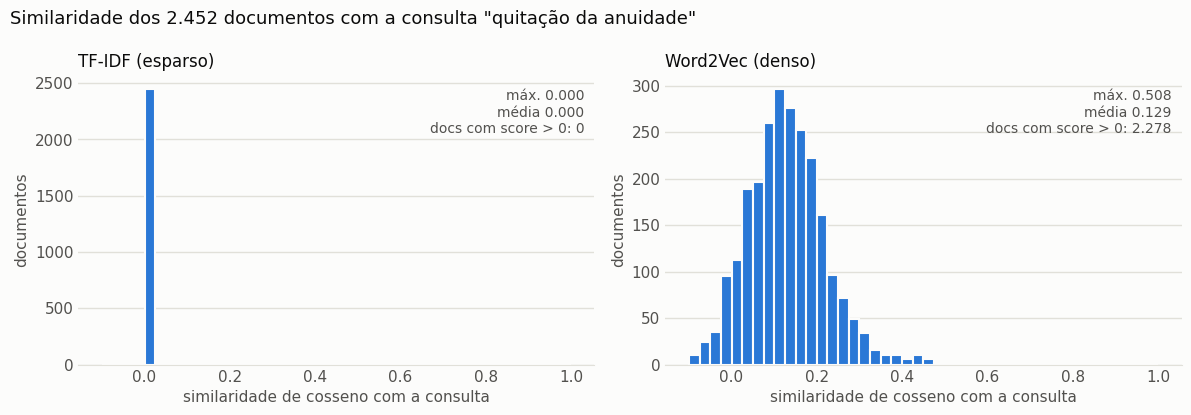

In [21]:
# Paleta e estilo herdados do TP1
SUPERFICIE, TINTA, SECUNDARIA, GRADE = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
AZUL = "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "text.color": TINTA, "axes.labelcolor": SECUNDARIA,
    "xtick.color": SECUNDARIA, "ytick.color": SECUNDARIA,
    "font.family": "DejaVu Sans", "font.size": 11,
})

fig, eixos = plt.subplots(1, 2, figsize=(12, 4.2))
faixas = np.linspace(-0.1, 1.0, 45)

for eixo, similaridades, titulo in [
    (eixos[0], sim_tfidf_estresse, "TF-IDF (esparso)"),
    (eixos[1], sim_w2v_estresse, "Word2Vec (denso)"),
]:
    eixo.hist(similaridades, bins=faixas, color=AZUL, edgecolor=SUPERFICIE, linewidth=1.5)
    eixo.set_title(titulo, loc="left", fontsize=12, color=TINTA)
    eixo.set_xlabel("similaridade de cosseno com a consulta")
    eixo.yaxis.grid(True, color=GRADE, linewidth=1)
    eixo.set_axisbelow(True)
    for lado in ("top", "right", "left"):
        eixo.spines[lado].set_visible(False)
    eixo.spines["bottom"].set_color(GRADE)
    eixo.tick_params(length=0)
    eixo.text(0.98, 0.95,
              f"máx. {similaridades.max():.3f}\nmédia {similaridades.mean():.3f}\n"
              f"docs com score > 0: {(similaridades > 0).sum():,}".replace(",", "."),
              transform=eixo.transAxes, ha="right", va="top", fontsize=10, color=SECUNDARIA)

for eixo in eixos:
    eixo.set_ylabel("documentos")
fig.suptitle(f"Similaridade dos {n_docs:,}".replace(",", ".") + f" documentos com a consulta \"{CONSULTA_ESTRESSE}\"",
             x=0.01, ha="left", fontsize=13, color=TINTA)
plt.tight_layout()
plt.show()

### 5.6 Segundo teste: onde a média de embeddings começa a ceder

Um segundo teste, com o mesmo desenho, sobre outro tema do corpus a qualidade do corpo docente. O corpus fala em `professor`, `tutor`, `tutoria`; a consulta usa dois termos ausentes:

> **"docentes e educadores"**

In [22]:
CONSULTA_ESTRESSE_2 = "docentes e educadores"

tokens_2 = pipeline.processar(CONSULTA_ESTRESSE_2)
assert all(t not in vetorizador_tfidf.vocabulary_ for t in tokens_2)
assert not re.search(r"\b(docent|educador)", texto_bruto)

resultado_tfidf_2, _ = buscar_tfidf(CONSULTA_ESTRESSE_2)
print()
resultado_w2v_2, _ = buscar_word2vec(CONSULTA_ESTRESSE_2)
display(resultado_w2v_2)

for palavra in tokens_para_embedding(tokens_2):
    print(f"\nVizinhos de '{palavra}' no vocabulário do corpus")
    display(vizinhos_no_corpus(palavra, n=6))

Consulta ............... 'docentes e educadores'
Tokens da consulta ..... ['docente', 'educador']
No vocabulário TF-IDF .. []
Fora do vocabulário .... ['docente', 'educador']
Componentes não nulos .. 0 de 3,951
Documentos com score > 0  0 de 2,452

>>> VETOR DA CONSULTA NULO: nenhum termo em comum com o vocabulário.
>>> Todos os scores são 0 e a ordem abaixo é arbitrária (índice do DataFrame),
>>> não um resultado de relevância.

Consulta ............... 'docentes e educadores'
Tokens da consulta ..... ['docente', 'educador']
Com embedding .......... ['docente', 'educador']
Sem embedding .......... []


,doc_id,posição,similaridade,instituicao,nota,texto
0,1300,1,0.4666,UNIASSELVI,5,"A Uniasselvi não é apenas um ensino, é uma carreira de aprendizado profissional. Sou Acadêmica da instituição polo Manaíra João Pessoa. ❤️ super indico 🏅"
1,1579,2,0.4276,Cruzeiro do Sul Virtual,5,"Excelente escola, se aprende, tem suporte, ajuda dos professores, estrutura excelente para os alunos!"
2,2451,3,0.4220,Senac,5,Muito bom! Visão geral do acadêmico Senac.



Vizinhos de 'docente' no vocabulário do corpus


,termo do corpus,cosseno Word2Vec,cosseno TF-IDF
0,acadêmica,0.474,0.0
1,professor,0.466,0.0
2,pedagógico,0.436,0.0
3,enfermagem,0.424,0.0
4,professores,0.419,0.0
5,pedagogia,0.416,0.0



Vizinhos de 'educador' no vocabulário do corpus


,termo do corpus,cosseno Word2Vec,cosseno TF-IDF
0,renomado,0.607,0.0
1,matemático,0.586,0.0
2,professor,0.552,0.0
3,acadêmico,0.509,0.0
4,consultor,0.441,0.0
5,designer,0.441,0.0


O TF-IDF falha pelo mesmo motivo e da mesma forma: vetor nulo, scores zerados. O Word2Vec continua saindo da estaca zero e chega ao campo certo os três documentos são avaliações sobre a experiência acadêmica, mas só um deles fala de fato dos professores; os outros dois são elogios genéricos em que a palavra `acadêmico`/`acadêmica` pesa mais que qualquer referência ao corpo docente. A explicação está nos vizinhos: *docente* fica perto de `acadêmica` antes de `professor`, e educador tem como vizinhos no corpus `renomado`, `matemático` e `designer`, reflexo do uso dessas palavras nos textos jornalísticos em que o NILC foi treinado. Com apenas duas palavras na consulta, cada vizinhança espúria desloca o centroide, e o ranking perde especificidade. A Seção 6.3 retoma essa limitação.

## 6. Análise Crítica Comparativa

### 6.1 Por que o TF-IDF falha sem correspondência exata

**O espaço vetorial do TF-IDF é gerado pela base canônica do vocabulário.** Cada termo $t$ é um eixo próprio, representado pelo vetor unitário $\mathbf{e}_t$, e cada documento é uma combinação linear desses eixos:

$$
\mathbf{d} = \sum_{t \in V} w_{t,d}\, \mathbf{e}_t, \qquad \mathbf{e}_i \cdot \mathbf{e}_j = \begin{cases} 1 & i = j \\ 0 & i \neq j \end{cases}
$$

A condição de ortogonalidade à direita é a raiz da falha. Ela diz que **dois termos diferentes são, por construção, perpendiculares** — o modelo não tem nenhum mecanismo para representar que dois termos significam coisas parecidas. `anuidade` e `mensalidade` estão a 90° um do outro, exatamente como `anuidade` e `wifi`. O TF-IDF assume independência total entre termos; a informação de sinonímia simplesmente não existe na representação.

**A consequência sobre o cosseno.** Expandindo o produto escalar com a propriedade acima, todos os termos cruzados se anulam e resta:

$$
\cos(\mathbf{q}, \mathbf{d}) = \frac{\mathbf{q}\cdot\mathbf{d}}{\lVert \mathbf{q}\rVert\,\lVert \mathbf{d}\rVert} = \frac{\displaystyle\sum_{t \,\in\, T_q \cap T_d} w_{t,q}\, w_{t,d}}{\lVert \mathbf{q}\rVert\,\lVert \mathbf{d}\rVert}
$$

**Só os termos presentes simultaneamente na consulta e no documento contribuem para a similaridade.** Se $T_q \cap T_d = \varnothing$, o numerador é uma soma vazia, e o cosseno é zero — independentemente do quanto o documento trate do mesmo assunto. O motor léxico mede sobreposição de vocabulário, não proximidade de significado.

**O caso extremo do teste de estresse.** Na consulta *"quitação da anuidade"*, a interseção é vazia não só com cada documento, mas com o vocabulário inteiro: `quitação` e `anuidade` não são colunas da matriz, porque o `TfidfVectorizer` só conhece os termos vistos no `fit`. Ao projetar a consulta com `transform`, os dois termos são descartados e o resultado é o **vetor nulo** — 0 componentes não nulos de alguns milhares, como a Seção 5.2 mostrou. O cosseno $\frac{0}{0}$ é indefinido, o scikit-learn devolve 0 para os 2.452 documentos, e o "top 3" que o motor exibe é apenas a ordem das linhas no DataFrame. O histograma da Seção 5.5 torna isso visível: toda a massa do TF-IDF está concentrada numa única barra em zero.

**O papel da esparsidade.** A matriz tem densidade abaixo de 0,4%: cada avaliação ativa, em média, pouco mais de uma dezena de eixos entre milhares. Em textos curtos e informais, a probabilidade de que duas descrições do mesmo problema escolham exatamente as mesmas palavras é baixa, e cada escolha diferente é um eixo ortogonal a mais. Por isso o problema não se restringe a consultas "adversárias" como a do teste: mesmo com correspondência parcial, o TF-IDF pontua documentos pelo termo coincidente, que muitas vezes é o menos informativo da consulta. A normalização lexical do TP1 mitiga a parte **morfológica** do problema — `cobrado`, `cobraram` e `cobrando` passam a coincidir em `cobrar` —, mas nenhuma lematização transforma `anuidade` em `mensalidade`. A variação **lexical** (sinonímia) está fora do alcance de qualquer representação baseada em contagem de termos.

### 6.2 Como o espaço contínuo do Word2Vec aproxima termos correlatos

**Um espaço de dimensão fixa, sem eixos dedicados a palavras.** No Word2Vec, cada palavra é um ponto $\mathbf{w}_t \in \mathbb{R}^{300}$, e as 300 coordenadas não correspondem a termos: são coordenadas latentes, compartilhadas por todo o vocabulário. O sentido é distribuído por todas as dimensões — daí a matriz de documentos da Seção 4.3 não ter nenhum zero. Nesse espaço, a ortogonalidade deixa de ser uma imposição da construção e passa a ser uma exceção: quaisquer duas palavras têm um cosseno contínuo entre −1 e 1, e esse valor é **aprendido a partir de dados**.

**O que o treinamento aprende: a hipótese distribucional.** O skip-gram ajusta os vetores para que cada palavra preveja as palavras que aparecem à sua volta numa janela de contexto. Com amostragem negativa, o objetivo aproxima o produto escalar $\mathbf{w}_t \cdot \mathbf{c}$ das palavras que coocorrem e afasta o das que não coocorrem. Duas palavras que aparecem nos **mesmos contextos** recebem gradientes semelhantes e convergem para regiões próximas do espaço — mesmo que nunca apareçam juntas. É a formalização da hipótese distribucional de Harris e Firth: *palavras que ocorrem em contextos semelhantes tendem a ter significados semelhantes*. Nos 1,39 bilhão de tokens do NILC, *anuidade* e *mensalidade* são cercadas pelas mesmas palavras — *pagar*, *valor*, *atraso*, *cobrança*, *reajuste* —, e por isso terminam com cosseno de cerca de 0,74, como a Seção 5.4 mostrou. A relação de sinonímia que o TF-IDF não consegue representar está codificada na **geometria** do espaço.

**Da palavra ao documento: centroides.** O vetor médio posiciona cada documento no centroide de suas palavras. Como a média é uma operação linear, o produto escalar entre consulta e documento — o numerador do cosseno — se decompõe nas similaridades entre **todos os pares** de palavras, e não apenas entre palavras idênticas:

$$
\mathbf{q}\cdot\mathbf{d} = \frac{1}{|T_q|\,|T_d|}\sum_{i \in T_q}\sum_{j \in T_d} \mathbf{w}_i \cdot \mathbf{w}_j
$$

Compare com a fórmula da Seção 6.1: lá, a soma percorria apenas a interseção $T_q \cap T_d$, porque todo termo cruzado era multiplicado por $\mathbf{e}_i\cdot\mathbf{e}_j = 0$. Aqui, **todos os termos cruzados contribuem**, ponderados pela proximidade semântica. `anuidade` contribui para o score de um documento que contém `mensalidade` em proporção a $\mathbf{w}_{\text{anuidade}}\cdot\mathbf{w}_{\text{mensalidade}}$. É por isso que o centroide de *"quitação da anuidade"* cai na região financeira do espaço, e os três documentos mais próximos tratam de boletos, mensalidades e pagamentos — sem compartilhar uma única palavra com a consulta.

**A origem do conhecimento.** Vale notar de onde vem essa capacidade: o corpus deste trabalho nunca menciona *anuidade*. O motor semântico recupera os documentos certos porque o modelo pré-treinado **transfere** conhecimento léxico aprendido num corpus externo dezenas de milhares de vezes maior. Isso também justifica, retrospectivamente, a decisão da Seção 4.1 de não treinar um Word2Vec próprio: um modelo treinado só sobre as avaliações não teria vetor para nenhuma das palavras da consulta.

### 6.3 Limitações observadas e o que elas indicam

O teste mostra a vantagem do espaço denso, mas os resultados também expõem seus custos — e é a combinação dos dois lados que fundamenta uma escolha de arquitetura.

| Aspecto | TF-IDF (esparso) | Word2Vec médio (denso) |
|---|---|---|
| Sinônimos e paráfrases | Similaridade zero por construção | Capturados pela geometria do espaço |
| Correspondência exata | Precisa; score interpretável termo a termo | Correta, mas sem vantagem sobre o TF-IDF |
| Negação | Preservada (`nao_funcionar` é um eixo próprio) | Perdida: o prefixo precisa ser removido e a média não representa polaridade |
| Ordem das palavras | Ignorada | Ignorada (a média é comutativa) |
| Escala dos scores | Zero para irrelevantes; separação nítida | Contínua: documentos sem relação ainda pontuam acima de zero, e não há ponto de corte natural |
| Diluição | Não se aplica | Termos genéricos puxam o centroide para uma região "média"; ver Seção 5.6 |
| Domínio | Aprende o vocabulário do próprio corpus | Herda o sentido dominante no corpus de treino (jornalístico): `travar` tem cosseno ≈ 0,69 com `suster` e ≈ 0,63 com `combater` (*travar uma batalha*), mas só ≈ 0,33 com `congelar` e ≈ 0 com `bugar` |
| Custo | Matriz esparsa pequena; treino em segundos | Modelo de ~1,1 GB em memória |

Três observações dos testes merecem destaque:

1. **A escala dos scores do Word2Vec exige cautela.** No histograma da Seção 5.5, quase todos os documentos do corpus — inclusive os que não têm nenhuma relação com pagamentos — recebem cosseno positivo com a consulta, e os scores formam um contínuo: não há um salto que separe os relevantes dos irrelevantes. Além disso, o melhor resultado do teste de estresse fica em torno de 0,5, contra mais de 0,9 na consulta de controle. Em uma aplicação, isso impede usar um limiar fixo para decidir "nenhum resultado relevante" — algo que o TF-IDF faz naturalmente com o score zero.
2. **A média dilui.** No segundo teste, o vetor de *educador* herda do corpus jornalístico uma vizinhança que inclui `renomado` e `designer`. Com apenas duas palavras na consulta, cada vizinhança espúria desloca o centroide, e o resultado perde especificidade. Documentos longos sofrem o efeito inverso: dezenas de palavras genéricas aproximam o centroide do centro do espaço.
3. **A perda da negação é real.** Para o Word2Vec médio, *"funciona"* e *"não funciona"* são praticamente o mesmo documento. No corpus deste trabalho, dominado por reclamações, isso é uma limitação relevante, e é exatamente o sinal que o pipeline do TP1 se esforçou para preservar.

**Conclusão.** Os dois motores não são substitutos, e sim complementares. O TF-IDF é preciso, interpretável e barato, mas falha por construção sempre que o usuário não usa as palavras da base — e, numa central de atendimento, o aluno quase nunca usa. O Word2Vec resolve a lacuna de vocabulário ao trocar eixos ortogonais por um espaço contínuo aprendido, pagando com perda de negação, compressão de scores e sensibilidade ao domínio de treino. Para a triagem proposta no TP1, a arquitetura indicada é **híbrida**: combinar os dois scores (por exemplo, uma média ponderada ou a fusão dos rankings), de modo que o TF-IDF garanta precisão quando há correspondência exata e o Word2Vec garanta cobertura quando não há. Os passos naturais seguintes seriam ponderar a média de embeddings pelo idf de cada termo — atenuando a diluição por palavras genéricas — e, adiante, substituir a média por embeddings de sentença treinados com contexto, que representam ordem e negação.

---

**Referência do modelo:** HARTMANN, N. et al. *Portuguese Word Embeddings: Evaluating on Word Analogies and Natural Language Tasks*. In: Simpósio Brasileiro de Tecnologia da Informação e da Linguagem Humana (STIL), 11., 2017. Modelos disponíveis em: http://nilc.icmc.usp.br/embeddings e https://huggingface.co/nilc-nlp.